# Загрузка библиотек

In [1]:
# Load libs
import numpy as np
import pandas as pd
from scipy import stats
from scipy.io import loadmat
from scipy.signal import butter, filtfilt
from scipy.fft import fft
from pathlib import Path
import matplotlib.pyplot as plt
import pywt
import glob
import os
from tqdm.notebook import tqdm

# 1. Чтение из .mat в df и визуализация исходных сигналов

In [2]:
# Просмотр данных
mat_file_path = './CWRU/raw_data/Normal_1797.mat'
mat_data = loadmat(mat_file_path)
for key in mat_data.keys():
    print(key, mat_data[key])

__header__ b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Mon Jan 31 15:28:20 2000'
__version__ 1.0
__globals__ []
X097_DE_time [[ 0.05319692]
 [ 0.08866154]
 [ 0.09971815]
 ...
 [-0.03463015]
 [ 0.01668923]
 [ 0.04693846]]
X097_FE_time [[0.14566727]
 [0.09779636]
 [0.05485636]
 ...
 [0.14053091]
 [0.09553636]
 [0.09019455]]
X097RPM [[1796]]


In [3]:
def mat_to_df_cwru(mat_file_path: str, use_DE=True, fs: int=12000, verbose: bool=False):
    """
    Функция для чтения данных CWRU из формата .mat.
    
    Input:
    -----------
    mat_file_path : str
        Путь к файлу .mat
    use_DE: bool, optional
        Выбор между FE и DE данными (по умолчанию DE)
    fs: int, optional
        Частота дискретизации (по умолчанию 12000)
    verbose : bool
        Если False, отключает все print сообщения
    
    Output:
    -----------
    df: DataFrame с исходным сигналом
    """
    if verbose:
        print(f"Чтение: {mat_file_path}")
    
    # Загрузка .mat файла
    mat_data = loadmat(mat_file_path)
    
    # Поиск массива с данными
    data_array = None
    for key in mat_data.keys():
        if not key.startswith('__'): # Пропуск метаданных
            if 'DE' in key and use_DE:
                data_array = mat_data[key].flatten()
            elif 'FE' in key and not use_DE:
                data_array = mat_data[key].flatten()
      
    if data_array is None:
        if verbose:
            print("Ошибка: не найден массив с данными")
        return None
    
    # Создание DataFrame
    df = pd.DataFrame({'Amplitude': data_array})
    
    return df

In [4]:
# test mat_to_df_cwru
test_df = mat_to_df_cwru('./CWRU/raw_data/OR007_1730.mat')
test_df

,Amplitude
0,-0.108425
1,-0.127105
2,0.098679
3,0.090964
4,0.053198
...,...
122566,0.194110
122567,-0.259084
122568,-0.244465
122569,0.139694


In [5]:
def visualize_cwru(df, save_plot=False, output_dir=None, fs: int = 12000):
    """
    Визуализация данных из df.
    
    Input:
    -----------
    df : pd.DataFrame
        df с исходным сигналом
    save_plot : bool, optional
        Сохранять ли график в файл
    output_dir : str, optional
        Директория для сохранения графика
    fs: int, optional
        Частота дискретизации (по умолчанию 12000)
    """
    amplitude_data = df['Amplitude']
    
    # Создание графика
    plt.figure(figsize=(12, 6))
    
    # Полный сигнал
    plt.subplot(2, 1, 1)
    plt.plot(df.index, df['Amplitude'], linewidth=0.5)
    plt.ylabel('Амплитуда')
    plt.grid(True)
    
    # ~Первые 0.1 секунды для детального просмотра
    plt.subplot(2, 1, 2)
    # Находим индексы для первых 0.1 секунды
    n_samples = int(0.1 * fs)
    segment = df.head(min(n_samples, len(df)))
    plt.plot(segment.index, segment['Amplitude'], linewidth=1, color='red')
    
    plt.ylabel('Амплитуда')
    plt.grid(True)
    
    plt.tight_layout()
    
    # Сохранение графика
    if save_plot:
        if output_dir:
            output_path = Path(output_dir)
            output_path.mkdir(parents=True, exist_ok=True)
            save_path = output_path / f"{Path(csv_file_path).stem}_plot.png"
        else:
            save_path = Path(csv_file_path).with_suffix('.png')
        
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"График сохранен: {save_path}")
    
    plt.show()

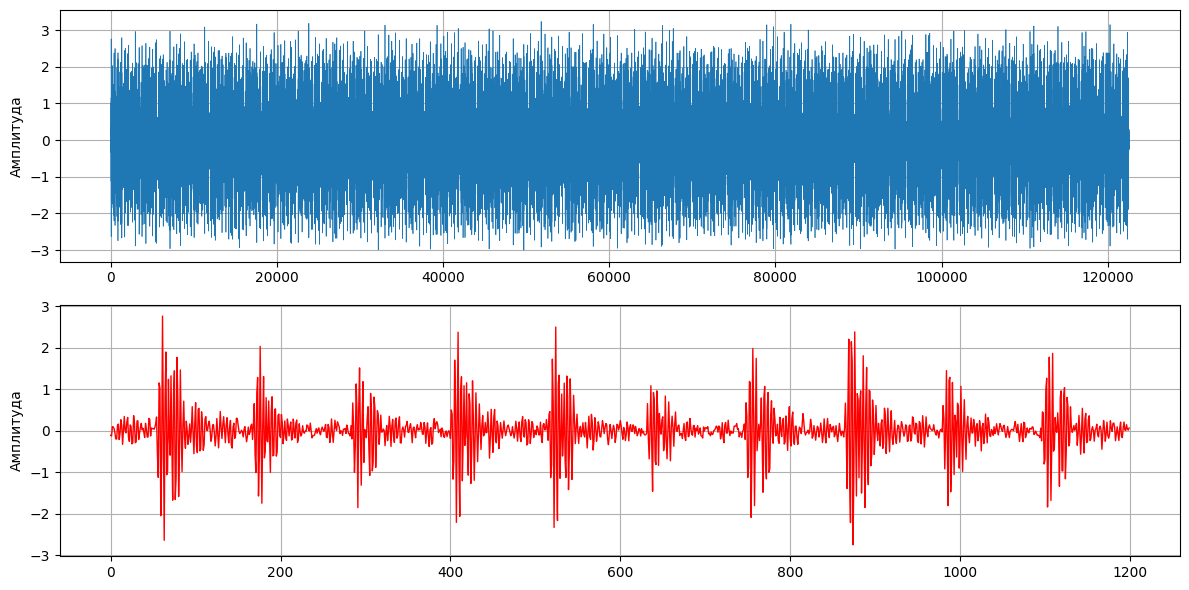

In [6]:
# test vis
visualize_cwru(test_df)

In [7]:
def visualize_cwru_frequency(df: pd.DataFrame, save_plot=False, output_dir=None, fs: int = 12000):
    """
    Визуализация сигнала в частотном диапзоне из df.
    
    Input:
    -----------
    df : pd.DataFrame
        df с исходным сигналом
    save_plot : bool, optional
        Сохранять ли график в файл
    output_dir : str, optional
        Директория для сохранения графика
    fs: int, optional
        Частота дискретизации (по умолчанию 12000)
    """
    amplitude_data = df['Amplitude'].values
    n = len(amplitude_data)
    
    # Вычисление БПФ
    fft_vals = np.abs(fft(amplitude_data))[:n//2]
    freqs = np.fft.fftfreq(n, 1/fs)[:n//2]
    
    # Нормализация амплитуды (делим на n/2 для корректного отображения)
    fft_vals_norm = fft_vals * 2.0 / n
    
    # Создание графика
    plt.figure(figsize=(12, 8))
    
    # Визуализация (для детального просмотра можно редактировать xlim)
    plt.subplot(2, 1, 1)
    plt.plot(freqs, fft_vals_norm, linewidth=0.5, color='blue')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Амплитуда')
    plt.grid(True, alpha=0.3)
    plt.xlim(0, fs/2)
    
    # Сохранение графика
    if save_plot:
        if output_dir:
            output_path = Path(output_dir)
            output_path.mkdir(parents=True, exist_ok=True)
            save_path = output_path / f"{Path(csv_file_path).stem}_frequency_plot.png"
        else:
            save_path = Path(csv_file_path).with_suffix('.png')
            save_path = save_path.with_stem(save_path.stem + '_frequency')
        
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"График АЧХ сохранен: {save_path}")
    
    plt.show()

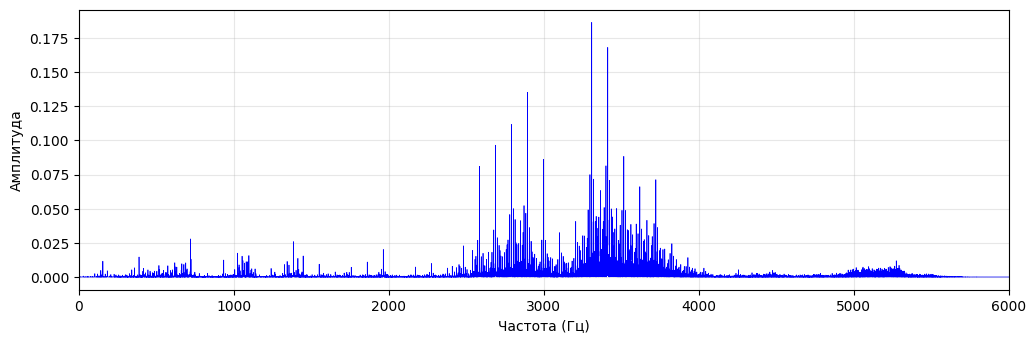

In [8]:
# test vis freq
visualize_cwru_frequency(test_df)

# 2. Предобработка данных

## 2.1 Фильтрация

In [6]:
def filter_signal(data, fs: int = 12000, lowcut: float = 10, highcut: float = 5000, order: int = 4, verbose: bool=False):
    """
    Фильтрация сигнала с помощью полосового фильтра Баттерворта.

    Input:
    -----------
    data: DataFrame
        Входной сигнал
    fs: int, optional
        Частота дискретизации (по умолчанию 12000)
    lowcut: float, optional
        Нижняя частота среза (по умолчанию 10)
    highcut: float, optional
        Верхняя частота среза (по умолчанию 5000)
    order: int, optional
        Порядок фильтра (по умолчанию 4)
    verbose : bool
        Если False, отключает все print сообщения

    Output:
    -----------
    filtered_data : DataFrame
        Отфильтрованный сигнал
    """
    if verbose:
        print(f"Частота дискретизации: {fs} Гц")
        print(f"Полоса пропускания: {lowcut}-{highcut} Гц")
        print(f"Порядок фильтра: {order}")

    # Нормализация частот
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    # Создание фильтра
    b, a = butter(order, [low, high], btype='band')

    # Применение фильтра
    filtered_amplitude = filtfilt(b, a, data['Amplitude'].values)
    filtered_data = pd.DataFrame({
        'Amplitude': filtered_amplitude
    })

    if verbose:
        print(f"Фильтрация завершена.")

    return filtered_data

In [10]:
# test filtering
filter_signal(test_df)

,Amplitude
0,0.163119
1,0.153158
2,0.350507
3,0.381918
4,0.297578
...,...
122566,0.154293
122567,-0.286587
122568,-0.278189
122569,0.107425


## 2.2 Сегментация

In [7]:
def segment_signal(data, fs: int=12000, window_size: int=1024, overlap=0.5, verbose: bool=False):
    """
    Сегментация сигнала с перекрытием.
    
    Input:
    -----------
    data : DataFrame
        Входной сигнал
    fs : int, optional
        Частота дискретизации (по умолчанию 12000)
    window_size: int, optional
        Размер окна в точках (по умолчанию 1024)
    overlap : float, optional
        Доля перекрытия окон (по умолчанию 0.5)
    verbose : bool
        Если False, отключает все print сообщения
    
    Output:
    -----------
    df_segments : ndarray
        Массив сегментов c формой (n_segments, window_size)
    """
    # Извлечение амлитуд и расчёт шага
    amplitude = data['Amplitude'].values
    step = int(window_size * (1 - overlap))
    
    if verbose:
        print(f"Размер окна: {window_size} отсчетов")
        print(f"Перекрытие: {overlap*100:.0f}%")
        print(f"Шаг: {step} отсчетов")
    
    # Сегментация
    segments_list = []
    
    for i in range(0, len(amplitude) - window_size + 1, step):
        segment = amplitude[i:i + window_size]
        segments_list.append(segment)
    
    # Итоговый массив сегментов (ndarray)
    segments = np.array(segments_list)

    if verbose:
        print(f"Всего сегментов: {len(segments)}")
    
    return segments

In [12]:
# test segmentation
nd_segments = segment_signal(test_df, verbose = True)
print(nd_segments.shape)

Размер окна: 1024 отсчетов
Перекрытие: 50%
Шаг: 512 отсчетов
Всего сегментов: 238
(238, 1024)


## 2.3 Извлечение признаков

## 2.3.1 Временные признаки

В качестве временных признаков будем извлекать:
1. Среднее;
2. Стандартное отклонение;
3. Среднеквадратичное значение;
4. Максимальное абсолютное значение;
5. Размах (max - min);
6. Ассиметрию;
7. Эксцесс.

In [8]:
def extract_time_features(segment):
    features = []
    features.append(np.mean(segment))                  # Среднее
    features.append(np.std(segment))                   # std
    features.append(np.sqrt(np.mean(segment**2)))      # СКЗ
    features.append(np.max(np.abs(segment)))           # Максимальное абсолютное значение
    features.append(np.max(segment) - np.min(segment)) # Размах
    features.append(stats.skew(segment))               # Асимметрия
    features.append(stats.kurtosis(segment))           # Эксцесс
    
    return np.array(features)

In [14]:
# test extraction time features
extract_time_features(nd_segments[0])

array([ 4.58514397e-03,  5.62788509e-01,  5.62807186e-01,  2.75977285e+00,
        5.50452046e+00, -8.51017136e-02,  5.13100195e+00])

## 2.3.2 Частотные признаки

Из частотной области будем извлекать:
1. Среднее значение амлитуды;
2. Стандартное отклонение амплитуды;
3. Спектральную энергию;
4. Частоту пиковой амплитуды;
5. Пиковую амплитуду;
6. Средневзвешенную частоту.

In [9]:
def extract_freq_features(segment, fs):
    # Переходим в частотную область (используем только положительные частоты) без нормировки
    n = len(segment)
    fft_vals = np.abs(fft(segment))[:n//2]
    freqs = np.fft.fftfreq(n, 1/fs)[:n//2]
    
    # Извлечение признаков
    features = []
    features.append(np.mean(fft_vals))                           # Среднее значение амлитуды
    features.append(np.std(fft_vals))                            # Стандартное отклонение амплитуды
    features.append(np.sum(fft_vals**2))                         # Спектральная энергия
    features.append(freqs[np.argmax(fft_vals)])                  # Частота пика
    features.append(np.max(fft_vals))                            # Пиковая амплитуда
    # Средневзвешенная частота (без деления на 0)
    total_amp = np.sum(fft_vals)
    if total_amp > 1e-6:
        features.append(np.sum(freqs * fft_vals) / total_amp)
    else:
        features.append(0.0)
    
    return np.array(features)

In [16]:
# test extraction freq features
extract_freq_features(nd_segments[0], 12000)

array([8.56963872e+00, 1.58409829e+01, 1.66080229e+05, 3.31640625e+03,
       1.31366618e+02, 3.15621318e+03])

## 2.3.3 Частотно-временные признаки

Из частотно-временной области будем извлекать:
1. Энергию;
2. Относительную энергию;
4. Стандартное отклонение;
5. Среднее;
6. Среднеквадратичное значение;
7. Размах;
8. Максимальное абсолютное значение.

После вейвлет-преобразования сигнал раскладывается на 5 уровней коэффициентов (при использования вейвлета 'db4'). Таким образом, для каждого сегмента формируется вектор из 35 признаков (5 уровней и 7 характеристик).

In [10]:
def extract_wavelet_features(segment, wavelet='db4', level=4):
    coeffs = pywt.wavedec(segment, wavelet, level=level)
    features = []
    # Полная энергия для относительной
    total_energy = np.sum([np.sum(np.square(c)) for c in coeffs])
    
    for i, coeff in enumerate(coeffs):
        # Вычисление статистик для набора коэффициентов
        if len(coeff) > 0:
            features.append(np.sum(coeff**2))                   # Энергия
            if total_energy > 0:
                features.append(features[-1] / total_energy)    # Относительная энергия
            else:
                features.append(0)
            features.append(np.std(coeff))                      # Стандартное отклонение
            features.append(np.mean(coeff))                     # Среднее
            features.append(np.sqrt(np.mean(np.square(coeff)))) # СКЗ
            features.append(np.max(coeff) - np.min(coeff))      # Размах
            features.append(np.max(np.abs(coeff)))              # Максимальное абсолютное значение
        else:
            features.extend([0, 0, 0, 0, 0, 0, 0])
            
    return np.array(features)

In [18]:
# Тестирование извлечение частотно-временных признаков
extract_wavelet_features(nd_segments[0]).shape

(35,)

## 2.3.4 Объединенное извлечение всех признаков

In [11]:
def create_feature_dataset(segments, fs=12000, wavelet='db4', level=4, verbose: bool=False):
    """
    Выделение временных, частотных и частотно-временных признаков для всех сегментов данных.

    Input:
    -----------
    segments: ndarray
        Массив сегментов (n_segments, window_samples)
    fs: int, optional
        Частота дискретизации (по умолчанию 12000)
    wavelet: str, optional
        Тип вейвлета для декомпозиции (по умолчанию 'db4')
    level: int, optional
        Уровень вейвлет-декомпозиции (по умолчанию 4)
    verbose : bool
        Если False, отключает все print сообщения
        
    Output:
    -----------
    df_features: DataFrame
        Датафрейм с признаками для всех сегментов.
    """
    if len(segments) == 0:
        return pd.DataFrame()

    # Названия признаков
    time_feature_names = [
        'time_mean',
        'time_std',
        'time_rms',
        'time_max_abs',
        'time_range',
        'time_skewness',
        'time_kurtosis'
    ]

    freq_feature_names = [
        'freq_mean_amp',
        'freq_std_amp',
        'freq_spec_energy',
        'freq_peak_freq',
        'freq_peak_amp',
        'freq_weighted_freq'
    ]

    wavelet_feature_base_names = [
        'energy',
        'rel_energy',
        'std',
        'mean',
        'rms',
        'range',
        'max_abs'
    ]

    wavelet_feature_names = []
    for i in range(level + 1):
        level_name = f'cA' if i == 0 else f'cD{i}'
        for base_name in wavelet_feature_base_names:
            wavelet_feature_names.append(f'wavelet_{level_name}_{base_name}')

    all_feature_names = time_feature_names + freq_feature_names + wavelet_feature_names

    # Извлечение признаков для всех сегментов
    all_features = []
    
    for i, segment in enumerate(segments):
        time_feats = extract_time_features(segment)
        freq_feats = extract_freq_features(segment, fs)
        wavelet_feats = extract_wavelet_features(segment, wavelet, level)

        # Проверка размерности
        expected_wavelet_len = (level + 1) * 7
        if len(wavelet_feats) != expected_wavelet_len:
            if verbose:
                print(f"Предупреждение: сегмент {i}: ожидалось {expected_wavelet_len} вейвлет-признаков, получено {len(wavelet_feats)}")

        full_feature_vector = np.concatenate([time_feats, freq_feats, wavelet_feats])
        
        all_features.append(full_feature_vector)

    # Формирование df для возврата
    df_features = pd.DataFrame(all_features, columns=all_feature_names)
    df_features.index.name = 'segment_id'
    
    return df_features

In [20]:
# Тестирование извлечения всех признаков
test_full_feats_df = create_feature_dataset(nd_segments)
test_full_feats_df

,time_mean,time_std,time_rms,time_max_abs,time_range,time_skewness,time_kurtosis,freq_mean_amp,freq_std_amp,freq_spec_energy,...,wavelet_cD3_rms,wavelet_cD3_range,wavelet_cD3_max_abs,wavelet_cD4_energy,wavelet_cD4_rel_energy,wavelet_cD4_std,wavelet_cD4_mean,wavelet_cD4_rms,wavelet_cD4_range,wavelet_cD4_max_abs
segment_id,,,,,,,,,,,,,,,,,,,,,
0,0.004585,0.562789,0.562807,2.759773,5.504520,-0.085102,5.131002,8.569639,15.840983,166080.228679,...,0.633596,4.657315,2.478505,215.652264,0.663701,0.647103,-0.000027,0.647103,6.452768,3.397769
1,0.004682,0.551271,0.551291,2.792260,5.537007,-0.094935,5.581885,8.378253,15.525578,159354.212297,...,0.635480,4.886601,2.707792,202.298736,0.647615,0.626748,-0.000344,0.626748,6.452768,3.397769
2,0.004521,0.562008,0.562026,2.792260,5.459851,0.112366,5.181156,8.771364,15.701510,165618.810547,...,0.582868,4.402543,2.707792,235.686563,0.712846,0.676491,0.001844,0.676494,5.633294,2.918586
3,0.004449,0.585822,0.585839,2.643632,5.228787,0.170465,4.130853,8.764148,16.572689,179949.720240,...,0.690478,5.258803,3.130889,222.052675,0.630700,0.656636,-0.000159,0.656636,5.633294,2.918586
4,0.003785,0.575910,0.575923,2.959974,5.847665,0.065930,4.933050,9.361474,15.875296,173907.060873,...,0.728933,5.323028,3.195114,204.133843,0.569177,0.629584,0.000476,0.629584,5.429434,2.887552
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233,0.004382,0.627056,0.627072,3.147587,6.036496,0.097764,4.623279,9.708462,17.561927,206169.865661,...,0.682273,5.728022,2.951050,277.574607,0.686566,0.734152,-0.000689,0.734152,6.180032,3.254561
234,0.005599,0.615023,0.615049,3.147587,6.036496,0.057924,4.518422,9.297767,17.347831,198346.606227,...,0.686439,5.265137,2.951050,262.042809,0.653599,0.713313,-0.002394,0.713317,5.620817,2.910355
235,0.004092,0.548560,0.548575,2.624140,5.152848,-0.018976,4.620976,8.842737,15.165099,157785.200891,...,0.647321,5.323204,3.009118,200.332344,0.627475,0.623692,0.001740,0.623695,5.202692,2.604930


# 2.4 Полный пайплайн подготовки данных

## 2.4.1 Общий пайплан

In [21]:
def preprocessing_pipeline(
    df: pd.DataFrame,
    fs: int = 12000,
    filter_lowcut: float = 10,
    filter_highcut: float = 5000,
    filter_order: int = 4,
    window_size: int = 1024,
    overlap: float = 0.5,
    wavelet: str = 'db4',
    wavelet_level: int = 4,
    verbose: bool = False
):
    """
    Основная часть пайплайна предобработки. Ожидает на вход df, представляющий собой сигнал из одного файла набора данных (CWRU/IMS).
    Важно: Если объединить несколько файлов в один df, то сегментация не сможет корректно разделить файлы.

    Input:
    -----------
    df: pd.DataFrame
        DataFrame, содержащий вибрационный сигнал из одного файла датасета.
    Остальные аргументы описаны в других функциях.
        
    Output:
    -----------
    df_features: DataFrame
        Датафрейм с признаками по сегментам для одного файла.
    """
    if verbose:
        print("="*60)
        print("ПРЕДОБРАБОТКА ДАННЫХ")
        print("="*60)

    # Шаг 1: Фильтрация сигнала
    if verbose:
        print("\n[1/3] Фильтрация сигнала")
        print("-" * 40)

    df_filtered_signal = filter_signal(
        df,
        fs=fs,
        lowcut=filter_lowcut,
        highcut=filter_highcut,
        order=filter_order,
        verbose=verbose
    )
    
    # Шаг 2: Сегментация сигнала
    if verbose:
        print("\n[2/3] СЕГМЕНТАЦИЯ СИГНАЛА")
        print("-" * 40)

    nd_segments = segment_signal(
        df_filtered_signal,
        fs=fs,
        window_size=window_size,
        overlap=overlap,
        verbose = verbose
    )

    if len(nd_segments) == 0:
        if verbose:
            print("ОШИБКА: не создано ни одного сегмента")
        return pd.DataFrame()

    # Шаг 3: Извлечение признаков
    if verbose:
        print("\n[3/3] ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ")
        print("-" * 40)

    df_features = create_feature_dataset(
        nd_segments,
        fs=fs,
        wavelet=wavelet,
        level=wavelet_level,
        verbose = verbose
    )

    if verbose:
        print(f"Извлечено признаков: {len(df_features.columns)}")
        print(f"Количество сегментов: {len(df_features)}")

    if verbose:
        print("\n" + "="*60)
        print("ПРЕДОБРАБОТКА ЗАВЕРШЕНА")
        print("="*60)

    return df_features

In [22]:
test_proc_pipeline = preprocessing_pipeline(df = test_df, verbose=True)
test_proc_pipeline

ПРЕДОБРАБОТКА ДАННЫХ

[1/3] Фильтрация сигнала
----------------------------------------
Частота дискретизации: 12000 Гц
Полоса пропускания: 10-5000 Гц
Порядок фильтра: 4
Фильтрация завершена.

[2/3] СЕГМЕНТАЦИЯ СИГНАЛА
----------------------------------------
Размер окна: 1024 отсчетов
Перекрытие: 50%
Шаг: 512 отсчетов
Всего сегментов: 238

[3/3] ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ
----------------------------------------
Извлечено признаков: 48
Количество сегментов: 238

ПРЕДОБРАБОТКА ЗАВЕРШЕНА


,time_mean,time_std,time_rms,time_max_abs,time_range,time_skewness,time_kurtosis,freq_mean_amp,freq_std_amp,freq_spec_energy,...,wavelet_cD3_rms,wavelet_cD3_range,wavelet_cD3_max_abs,wavelet_cD4_energy,wavelet_cD4_rel_energy,wavelet_cD4_std,wavelet_cD4_mean,wavelet_cD4_rms,wavelet_cD4_range,wavelet_cD4_max_abs
segment_id,,,,,,,,,,,,,,,,,,,,,
0,0.028040,0.566142,0.566836,2.967332,5.697572,0.002974,4.990804,8.543092,16.026086,168867.758791,...,0.633774,4.655778,2.477820,212.297309,0.632997,0.642050,0.000032,0.642050,6.427289,3.357064
1,-0.006501,0.548075,0.548113,2.820107,5.550346,-0.045609,5.586666,7.959989,15.630741,157532.921649,...,0.635438,4.884964,2.707006,198.359742,0.643317,0.620616,-0.000353,0.620616,6.427289,3.357064
2,0.003148,0.557837,0.557846,2.820107,5.488425,0.085066,5.182302,8.361975,15.771702,163158.638336,...,0.582553,4.386875,2.707006,230.704765,0.708465,0.669304,0.001535,0.669306,5.641179,2.912113
3,-0.001149,0.582308,0.582309,2.660211,5.227265,0.113578,4.126473,8.285140,16.690693,177778.061448,...,0.690426,5.258320,3.130289,217.868824,0.626321,0.650420,-0.000111,0.650420,5.641179,2.912113
4,-0.000755,0.573404,0.573404,2.938832,5.816041,0.059465,4.958262,9.008333,15.985417,172382.018119,...,0.729400,5.322576,3.194544,201.088869,0.564598,0.624871,0.000176,0.624871,5.418591,2.895199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233,0.000235,0.624639,0.624639,3.152281,6.021469,0.109767,4.646002,9.333666,17.675411,204563.189448,...,0.682294,5.727595,2.950311,274.537842,0.684342,0.730125,-0.000844,0.730125,6.149387,3.207742
234,0.001356,0.612715,0.612716,3.152281,6.021469,0.084349,4.537064,8.956215,17.441880,196829.673665,...,0.686938,5.263957,2.950311,259.038557,0.650654,0.709212,-0.002425,0.709216,5.746935,2.885230
235,0.000408,0.544645,0.544645,2.619945,5.122683,-0.017479,4.615932,8.368649,15.288009,155523.845798,...,0.647493,5.322305,3.008659,195.623401,0.621674,0.616319,0.001440,0.616321,5.245323,2.650351


## 2.4.2 Полная предобработка файлов датасета CWRU

In [23]:
def cwru_preprocessing_pipeline(
    mat_file_path: str,
    fs: int = 12000, # for CWRU
    filter_lowcut: float = 10,
    filter_highcut: float = 5000,
    filter_order: int = 4,
    window_size: int = 1024,
    overlap: float = 0.5,
    wavelet: str = 'db4',
    wavelet_level: int = 4,
    verbose: bool = False
):
    df = mat_to_df_cwru(mat_file_path, fs=fs, verbose=verbose)

    if df is None:
        return pd.DataFrame()
    
    return preprocessing_pipeline(
        df,
        fs = fs,
        filter_lowcut = filter_lowcut,
        filter_highcut = filter_highcut,
        filter_order = filter_order,
        window_size = window_size,
        overlap = overlap,
        wavelet = wavelet,
        wavelet_level = wavelet_level,
        verbose = verbose
    )

In [24]:
# Тестирование с .mat-файлом
test_cwru_pipeline = cwru_preprocessing_pipeline(mat_file_path='./CWRU/raw_data/Normal_1797.mat', verbose=True)
test_cwru_pipeline

Чтение: ./CWRU/raw_data/Normal_1797.mat
ПРЕДОБРАБОТКА ДАННЫХ

[1/3] Фильтрация сигнала
----------------------------------------
Частота дискретизации: 12000 Гц
Полоса пропускания: 10-5000 Гц
Порядок фильтра: 4
Фильтрация завершена.

[2/3] СЕГМЕНТАЦИЯ СИГНАЛА
----------------------------------------
Размер окна: 1024 отсчетов
Перекрытие: 50%
Шаг: 512 отсчетов
Всего сегментов: 475

[3/3] ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ
----------------------------------------
Извлечено признаков: 48
Количество сегментов: 475

ПРЕДОБРАБОТКА ЗАВЕРШЕНА


,time_mean,time_std,time_rms,time_max_abs,time_range,time_skewness,time_kurtosis,freq_mean_amp,freq_std_amp,freq_spec_energy,...,wavelet_cD3_rms,wavelet_cD3_range,wavelet_cD3_max_abs,wavelet_cD4_energy,wavelet_cD4_rel_energy,wavelet_cD4_std,wavelet_cD4_mean,wavelet_cD4_rms,wavelet_cD4_range,wavelet_cD4_max_abs
segment_id,,,,,,,,,,,,,,,,,,,,,
0,-0.003597,0.075335,0.075421,0.231484,0.426172,-0.212093,-0.128934,0.949658,2.221751,2989.070763,...,0.046309,0.217238,0.120718,0.034642,0.005476,0.008202,0.000013,0.008202,0.045316,0.024963
1,0.001447,0.072574,0.072588,0.284855,0.484976,-0.160724,0.033228,0.886496,2.147501,2763.589014,...,0.045799,0.215964,0.120718,0.035443,0.006139,0.008296,0.000003,0.008296,0.053111,0.028148
2,-0.000503,0.069453,0.069454,0.284855,0.484976,-0.107123,0.188067,0.899425,2.032480,2529.248282,...,0.045391,0.194977,0.102474,0.035946,0.007037,0.008354,-0.000029,0.008355,0.050354,0.028148
3,-0.000654,0.072035,0.072038,0.197873,0.384332,0.081147,-0.306379,0.880149,2.130666,2720.973167,...,0.047807,0.214965,0.112800,0.036590,0.006084,0.008429,0.000001,0.008429,0.037693,0.018848
4,0.002179,0.076976,0.077006,0.221002,0.420347,0.049809,-0.375798,0.893748,2.297473,3111.510745,...,0.049224,0.245406,0.125896,0.035906,0.005528,0.008350,0.000018,0.008350,0.041265,0.020801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,0.000013,0.074957,0.074957,0.214446,0.403153,-0.103471,-0.414322,0.892163,2.226544,2945.768027,...,0.049358,0.225520,0.118481,0.036285,0.006016,0.008394,0.000022,0.008394,0.042892,0.023778
471,-0.002994,0.072743,0.072804,0.189976,0.378682,0.061765,-0.379055,0.874075,2.161670,2783.654581,...,0.049315,0.223688,0.118481,0.034629,0.005235,0.008200,-0.000002,0.008200,0.042713,0.023778
472,0.003513,0.074974,0.075056,0.199722,0.391283,0.102807,-0.459419,0.921616,2.220785,2960.006082,...,0.049174,0.224957,0.116064,0.033326,0.005524,0.008044,-0.000020,0.008044,0.036373,0.019039


Обработаем все файлы из датасета.

Выбранные файлы:
1. Нормальное состояние:
    * Motor load - 0 hp, motor speed - 1797 rpm;
    * Motor load - 1 hp, motor speed - 1772 rpm;
    * Motor load - 2 hp, motor speed - 1750 rpm;
    * Motor load - 3 hp, motor speed - 1730 rpm;
2. Аномальные состояния (все при минимальном диаметре - 0.007 дюймов):
    * Inner Race (при всех нагрузках);
    * Ball (при всех нагрузках);
    * Outer Race, Centered @6:00 (при всех нагрузках);


In [25]:
def process_all_cwru_files(
    input_pattern: str = "CWRU/raw_data/*",
    output_feat_dir: str = "CWRU/processed_features",
    fs: int = 12000, # for CWRU
    verbose: bool = False,
    **kwargs
):
    """
    Обрабатывает все файлы CWRU датасета и объединяет результаты в один DataFrame
    с добавлением метаинформации, содержащейся в названии файлов.
    
    Parameters:
    -----------
    input_pattern : str
        Шаблон для поиска ASCII файлов
    output_feat_dir : str
        Директория для сохранения результата
    fs : int
        Частота дискретизации
    verbose : bool
        Если False, отключает все print сообщения
    **kwargs : dict
        Дополнительные параметры для cwru_preprocessing_pipeline
    
    Returns:
    --------
    str
        Путь к созданному CSV файлу со всеми features извлеченными из датасета
    """
    # Находим все файлы
    mat_files = sorted(glob.glob(input_pattern))
    if verbose:
        print(f"Найдено файлов для обработки: {len(mat_files)}")

    if len(mat_files) == 0:
        if verbose:
            print("ОШИБКА: файлы не найдены!")
        return pd.DataFrame()
    
    # Список для хранения результатов
    all_features = []

    # Обработка каждого файла
    for i, mat_file in enumerate(mat_files):
        filename = Path(mat_file).name
        if verbose:
            print(f"\n[{i+1}/{len(mat_files)}] Обработка файла: {filename}")
        
        try:     
            # Применяем пайплайн предобработки
            features_df = cwru_preprocessing_pipeline(
                mat_file_path=mat_file,
                fs=fs,
                **kwargs
            )
            
            # Проверяем, что получили данные
            if features_df.empty:
                if verbose:
                    print(f"ПРЕДУПРЕЖДЕНИЕ: файл {filename} не дал результатов")
                continue

            # Добавляем мета информацию
            features_df['meta_fname'] = Path(filename).stem
            
            # Добавляем в общий список
            all_features.append(features_df)

            if verbose:
                print(f"Добавлено {len(features_df)} записей из файла {filename}")
            
        except Exception as e:
            if verbose:
                print(f"ОШИБКА при обработке {filename}: {str(e)}")
            continue

    if not all_features:
        if verbose:
            print("Нет обработанных данных!")
        return pd.DataFrame()
    
    # Объединяем все признаки
    if verbose:
        print("\n" + "="*60)
        print("ОБЪЕДИНЕНИЕ РЕЗУЛЬТАТОВ")
        print("="*60)

    combined_df = pd.concat(all_features, ignore_index=True)

    # Определение пути для сохранения
    output_path = Path(output_feat_dir)
    output_path.mkdir(exist_ok=True, parents=True)
    csv_path = output_path / "all_features.csv"

    # Сохранение в CSV
    combined_df.to_csv(csv_path, index=False)
    if verbose:
        print(f"Сохранено: {csv_path}")

    return csv_path

In [26]:
raw_cwru_folder_path = 'CWRU/raw_data/*'
process_all_cwru_files(raw_cwru_folder_path, verbose=True, fs=12000)

Найдено файлов для обработки: 16

[1/16] Обработка файла: Ball007_1730.mat
Добавлено 236 записей из файла Ball007_1730.mat

[2/16] Обработка файла: Ball007_1750.mat
Добавлено 236 записей из файла Ball007_1750.mat

[3/16] Обработка файла: Ball007_1772.mat
Добавлено 236 записей из файла Ball007_1772.mat

[4/16] Обработка файла: Ball007_1797.mat
Добавлено 238 записей из файла Ball007_1797.mat

[5/16] Обработка файла: IR007_1730.mat
Добавлено 239 записей из файла IR007_1730.mat

[6/16] Обработка файла: IR007_1750.mat
Добавлено 237 записей из файла IR007_1750.mat

[7/16] Обработка файла: IR007_1772.mat
Добавлено 237 записей из файла IR007_1772.mat

[8/16] Обработка файла: IR007_1797.mat
Добавлено 235 записей из файла IR007_1797.mat

[9/16] Обработка файла: Normal_1730.mat
Добавлено 947 записей из файла Normal_1730.mat

[10/16] Обработка файла: Normal_1750.mat
Добавлено 946 записей из файла Normal_1750.mat

[11/16] Обработка файла: Normal_1772.mat
Добавлено 944 записей из файла Normal_1772.m

WindowsPath('CWRU/processed_features/all_features.csv')

In [27]:
all_cwru_features = pd.read_csv('CWRU/processed_features/all_features.csv')
all_cwru_features

,time_mean,time_std,time_rms,time_max_abs,time_range,time_skewness,time_kurtosis,freq_mean_amp,freq_std_amp,freq_spec_energy,...,wavelet_cD3_range,wavelet_cD3_max_abs,wavelet_cD4_energy,wavelet_cD4_rel_energy,wavelet_cD4_std,wavelet_cD4_mean,wavelet_cD4_rms,wavelet_cD4_range,wavelet_cD4_max_abs,meta_fname
0,-0.010238,0.153009,0.153351,0.428232,0.856012,0.086607,-0.307485,2.545211,4.208359,12384.454749,...,0.964887,0.517516,13.074214,0.517604,0.159332,-0.000053,0.159332,0.895505,0.469939,Ball007_1730
1,0.002566,0.151738,0.151760,0.428232,0.856012,0.001277,-0.277374,2.344761,4.253552,12078.392209,...,0.903150,0.517516,13.448075,0.554629,0.161594,-0.000112,0.161594,0.895505,0.469939,Ball007_1730
2,-0.001552,0.153713,0.153721,0.622462,1.111616,0.039496,-0.090325,2.352344,4.320436,12390.239230,...,1.057677,0.590811,13.126830,0.528407,0.159652,0.000289,0.159653,0.791250,0.399718,Ball007_1730
3,0.000100,0.163555,0.163555,0.622462,1.128271,0.039261,-0.123080,2.363483,4.669703,14024.796457,...,1.049548,0.590811,15.442985,0.559691,0.173166,-0.000088,0.173166,0.947657,0.474694,Ball007_1730
4,0.000333,0.162725,0.162725,0.508992,1.014802,0.036814,-0.043531,2.515319,4.559405,13882.881210,...,0.910582,0.468414,14.783248,0.523686,0.169426,-0.000223,0.169426,0.947657,0.474694,Ball007_1730
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6150,-0.000217,0.695287,0.695287,3.298311,6.373129,0.025219,5.004533,10.420678,19.657959,253453.242213,...,6.776203,3.437150,319.289531,0.636280,0.787388,0.000638,0.787388,7.239056,3.655298,OR007_1797
6151,0.001817,0.707737,0.707739,3.217862,6.410308,0.031897,4.463327,9.917345,20.360880,262614.603949,...,6.663214,3.437150,321.368481,0.625963,0.789947,0.000404,0.789947,7.239056,3.655298,OR007_1797
6152,-0.007416,0.674969,0.675010,3.217862,6.410308,0.046149,4.183047,10.115284,19.086945,238914.777095,...,5.284416,3.093034,300.450615,0.629199,0.763804,-0.001684,0.763806,6.940109,3.496834,OR007_1797
6153,0.009983,0.640700,0.640778,2.764757,5.461963,0.045653,4.773204,9.640427,18.100141,215323.095069,...,6.606537,3.513503,238.522995,0.566372,0.680552,0.000036,0.680552,6.662531,3.496834,OR007_1797


## 2.4.3 Полная предобработка файлов датасета IMS

Файлы содержатся в формате ASCII, взглянем на них.

In [28]:
ascii_file_path = 'IMS\\raw_ASCII\\2004.02.12.10.32.39'
with open(ascii_file_path, 'r', encoding='ascii') as infile:
        lines = infile.readlines()
lines[0:10]

['-0.049\t-0.071\t-0.132\t-0.010\n',
 '-0.042\t-0.073\t-0.007\t-0.105\n',
 '0.015\t0.000\t0.007\t0.000\n',
 '-0.051\t0.020\t-0.002\t0.100\n',
 '-0.107\t0.010\t0.127\t0.054\n',
 '-0.078\t-0.212\t0.042\t-0.044\n',
 '-0.020\t-0.010\t-0.144\t-0.007\n',
 '-0.046\t0.112\t0.034\t0.034\n',
 '-0.063\t-0.154\t0.071\t0.076\n',
 '0.068\t0.044\t-0.029\t0.054\n']

В датасете No. 2 вышел из строя первый подшипник, данные с которого хранятся в первой колонке, будем выделять именно их. Также отметим, что частота дискретизации у данного датасета 20 кГц, а не 12 кГц (как у CWRU).

In [29]:
def ascii_to_df_bearing1(ascii_file_path, fs=20000, verbose=False):
    """
    Чтение ASCII файла IMS Bearing Data в df, извлекая только первый канал (Bearing 1).
    """
    if verbose:
        print(f"Чтение: {ascii_file_path}")

    data_array = []

    with open(ascii_file_path, 'r', encoding='ascii') as f:
        for line in f:
            line = line.strip()
            if line:
                # Берем только первое значение (первая колонка)
                value = float(line.split('\t')[0])
                data_array.append(value)

    # Преобразуем в массив
    data_array = np.array(data_array)
    
    if len(data_array) > 0:
        if verbose:
            print(f"Загружено {len(data_array)} отсчетов")
    else:
        if verbose:
            print("Ошибка: не найден массив с данными")
        return None
    
    # Создание DataFrame
    df = pd.DataFrame({
        'Amplitude': data_array
    })
    
    return df

In [30]:
# test ascii to df
test_df_IMS = ascii_to_df_bearing1('IMS\\raw_ASCII\\2004.02.12.10.32.39')
test_df_IMS

,Amplitude
0,-0.049
1,-0.042
2,0.015
3,-0.051
4,-0.107
...,...
20475,0.049
20476,0.037
20477,-0.012
20478,-0.012


### Пайплайн для IMS

In [33]:
def ims_preprocessing_pipeline(
    ascii_file_path: str,
    fs: int = 20000, # for IMS
    filter_lowcut: float = 10,
    filter_highcut: float = 5000,
    filter_order: int = 4,
    window_size: int = 1024,
    overlap: float = 0.5,
    wavelet: str = 'db4',
    wavelet_level: int = 4,
    verbose: bool = False
):
    """
    Обработка одного файла датасета.
    """
    df = ascii_to_df_bearing1(ascii_file_path, fs = fs, verbose = verbose)
    
    if df is None:
        return pd.DataFrame()
    
    return preprocessing_pipeline(
        df,
        fs = fs,
        filter_lowcut = filter_lowcut,
        filter_highcut = filter_highcut,
        filter_order = filter_order,
        window_size = window_size,
        overlap = overlap,
        wavelet = wavelet,
        wavelet_level = wavelet_level,
        verbose = verbose
    )

In [34]:
# test ims_preprocessing_pipeline
ims_preprocessing_pipeline('IMS\\raw_ASCII\\2004.02.12.10.32.39').head()

,time_mean,time_std,time_rms,time_max_abs,time_range,time_skewness,time_kurtosis,freq_mean_amp,freq_std_amp,freq_spec_energy,...,wavelet_cD3_rms,wavelet_cD3_range,wavelet_cD3_max_abs,wavelet_cD4_energy,wavelet_cD4_rel_energy,wavelet_cD4_std,wavelet_cD4_mean,wavelet_cD4_rms,wavelet_cD4_range,wavelet_cD4_max_abs
segment_id,,,,,,,,,,,,,,,,,,,,,
0,0.004505,0.061131,0.061297,0.185451,0.370243,0.096978,-0.110093,1.147976,1.597009,1980.562322,...,0.074316,0.455489,0.249309,0.334615,0.085152,0.025490,0.000015,0.025490,0.191953,0.100116
1,0.001797,0.065093,0.065118,0.219021,0.405815,0.041413,0.102433,1.200407,1.704245,2224.859022,...,0.082340,0.561866,0.301271,0.397611,0.088648,0.027786,-0.000011,0.027786,0.191953,0.100116
2,0.000733,0.065384,0.065388,0.219021,0.414781,-0.010965,0.094662,1.215419,1.703401,2241.954647,...,0.073398,0.561866,0.301271,0.295183,0.062275,0.023941,0.000016,0.023941,0.172951,0.091079
3,-0.000989,0.070505,0.070512,0.270222,0.480579,-0.112812,0.482162,1.278002,1.859837,2607.249240,...,0.078245,0.493042,0.266535,0.311963,0.055998,0.024612,0.000059,0.024612,0.167517,0.089519
4,-0.001056,0.068104,0.068112,0.270222,0.480579,-0.101927,0.643559,1.254486,1.782690,2432.879505,...,0.080709,0.502709,0.266535,0.319387,0.052699,0.024903,-0.000042,0.024903,0.161032,0.089519


Обработаем все файлы датасета.

In [35]:
def process_all_ims_files(
    input_pattern: str = "IMS/raw_ASCII/*",
    output_feat_dir: str = "IMS/processed_features",
    fs: int = 20000,
    verbose: bool = False,
    **kwargs
):
    # Находим все файлы
    ascii_files = sorted(glob.glob(input_pattern))
    if verbose:
        print(f"Найдено файлов для обработки: {len(ascii_files)}")

    if len(ascii_files) == 0:
        if verbose:
            print("ОШИБКА: файлы не найдены!")
        return pd.DataFrame()

    # Список для хранения результатов
    all_features = []

    # Обработка каждого файла
    for i, ascii_file in tqdm(enumerate(ascii_files)):
        filename = Path(ascii_file).name
        if verbose:
            print(f"[{i+1}/{len(ascii_files)}] Обработка файла: {filename}")
        
        try:     
            # Применяем пайплайн предобработки
            features_df = ims_preprocessing_pipeline(
                ascii_file_path=ascii_file,
                fs=fs,
                **kwargs
            )
            
            # Проверяем, что получили данные
            if features_df.empty:
                if verbose:
                    print(f"ПРЕДУПРЕЖДЕНИЕ: файл {filename} не дал результатов")
                continue

            # Добавляем метаинформацию (индекс файла)
            features_df['meta_fidx'] = i
            
            # Добавляем в общий список
            all_features.append(features_df)

            if verbose:
                print(f"Добавлено {len(features_df)} записей из файла {filename}")
            
        except Exception as e:
            if verbose:
                print(f"ОШИБКА при обработке {filename}: {str(e)}")
            import traceback
            traceback.print_exc()
            continue

    if not all_features:
        if verbose:
            print("Нет обработанных данных!")
        return pd.DataFrame()
    
    # Объединяем все признаки
    if verbose:
        print("\n" + "="*60)
        print("ОБЪЕДИНЕНИЕ РЕЗУЛЬТАТОВ")
        print("="*60)

    combined_df = pd.concat(all_features, ignore_index=True)

    # Определение пути для сохранения
    output_path = Path(output_feat_dir)
    output_path.mkdir(exist_ok=True, parents=True)
    csv_path = output_path / "all_features.csv"

    # Сохранение в CSV
    combined_df.to_csv(csv_path, index=False)
    if verbose:
        print(f"Сохранено: {csv_path}")

    return csv_path

In [ ]:
# Запуск предобработки
ascii_folder_path = 'IMS/raw_ASCII/*'
process_all_ims_files(ascii_folder_path)

In [36]:
all_ims_features = pd.read_csv('IMS/processed_features/all_features.csv')
all_ims_features

,time_mean,time_std,time_rms,time_max_abs,time_range,time_skewness,time_kurtosis,freq_mean_amp,freq_std_amp,freq_spec_energy,...,wavelet_cD3_range,wavelet_cD3_max_abs,wavelet_cD4_energy,wavelet_cD4_rel_energy,wavelet_cD4_std,wavelet_cD4_mean,wavelet_cD4_rms,wavelet_cD4_range,wavelet_cD4_max_abs,meta_fidx
0,0.004505,0.061131,0.061297,0.185451,0.370243,0.096978,-0.110093,1.147976,1.597009,1980.562322,...,0.455489,0.249309,0.334615,0.085152,0.025490,1.505809e-05,0.025490,0.191953,0.100116,0
1,0.001797,0.065093,0.065118,0.219021,0.405815,0.041413,0.102433,1.200407,1.704245,2224.859022,...,0.561866,0.301271,0.397611,0.088648,0.027786,-1.084516e-05,0.027786,0.191953,0.100116,0
2,0.000733,0.065384,0.065388,0.219021,0.414781,-0.010965,0.094662,1.215419,1.703401,2241.954647,...,0.561866,0.301271,0.295183,0.062275,0.023941,1.627292e-05,0.023941,0.172951,0.091079,0
3,-0.000989,0.070505,0.070512,0.270222,0.480579,-0.112812,0.482162,1.278002,1.859837,2607.249240,...,0.493042,0.266535,0.311963,0.055998,0.024612,5.902344e-05,0.024612,0.167517,0.089519,0
4,-0.001056,0.068104,0.068112,0.270222,0.480579,-0.101927,0.643559,1.254486,1.782690,2432.879505,...,0.502709,0.266535,0.319387,0.052699,0.024903,-4.225840e-05,0.024903,0.161032,0.089519,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38371,0.000002,0.000824,0.000824,0.003076,0.005252,0.747529,-0.753403,0.010687,0.024105,0.355962,...,0.002679,0.001410,0.000013,0.018249,0.000158,-3.854591e-07,0.000158,0.001309,0.000664,983
38372,0.000001,0.000800,0.000800,0.003076,0.003997,0.921013,-0.517156,0.010745,0.023248,0.335842,...,0.003050,0.001584,0.000013,0.020074,0.000162,1.403137e-07,0.000162,0.001309,0.000664,983
38373,0.000031,0.000790,0.000791,0.001801,0.002737,0.845308,-0.819768,0.010886,0.022870,0.328475,...,0.003150,0.001584,0.000012,0.018604,0.000153,-1.486240e-07,0.000153,0.001282,0.000666,983
38374,0.000007,0.000811,0.000811,0.002253,0.004054,0.683679,-0.950959,0.011087,0.023460,0.344728,...,0.003095,0.001566,0.000016,0.022600,0.000176,5.797870e-08,0.000176,0.001441,0.000736,983


Разделение на выборки, нормализация и PCA выполняется в train_std ноутбуке.